In [5]:
import json
from pathlib import Path
import pandas as pd
from krxns.network import construct_reaction_network, SuperMultiDiGraph
from hydra import compose, initialize
from ergochemics.draw import draw_reaction, draw_molecule
from ergochemics.standardize import standardize_smiles
from IPython.display import SVG
import networkx as nx
from functools import partial

with initialize(version_base=None, config_path="../configs"):
    cfg = compose("find_paths")

In [2]:
kcs = pd.read_csv(Path(cfg.filepaths.interim_data) / "compounds.csv")
sources = pd.read_csv(Path(cfg.filepaths.interim_data) / "default_sources.csv")
sources = sources['id'].tolist()
with open(Path(cfg.filepaths.interim_data) / "mass_contributions.json", 'r') as f:
    mass_contributions = json.load(f)

edges, nodes = construct_reaction_network(
    mass_contributions=mass_contributions,
    compounds=kcs,
    sources=sources,
    pnmc_lb=cfg.pnmc_lb,
    rnmc_lb=cfg.rnmc_lb,
    tot_mass_lb=0.7
)


In [20]:
G = SuperMultiDiGraph()
G.add_nodes_from(nodes)
G.add_edges_from(edges)

In [3]:
targets = pd.read_csv(Path(cfg.filepaths.artifacts) / "lbnl_targets.csv")
targets.head()

,id,smiles
0,tranexamicacid,NC[C@@H]1CC[C@@H](C(O)=O)CC1
1,permethrin,CC1(C(C1C(=O)OCC2=CC(=CC=C2)OC3=CC=CC=C3)C=C(C...


In [6]:
std_smi = partial(standardize_smiles, quiet=True, neutralization_method='simple')

In [7]:
targets['smiles'] = targets['smiles'].apply(std_smi)

In [8]:
targets.head()

,id,smiles
0,tranexamicacid,NCC1CCC(C(=O)O)CC1
1,permethrin,CC1(C)C(C=C(Cl)Cl)C1C(=O)OCc1cccc(Oc2ccccc2)c1


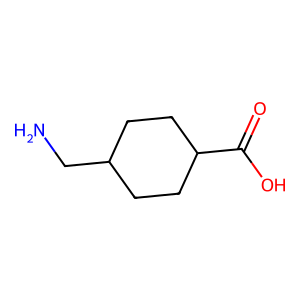

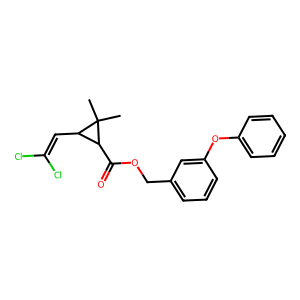

In [12]:
for smi in targets['smiles'].unique():
    display(SVG(draw_molecule(smi, size=(300, 300),)))

In [27]:
for _, row in targets.iterrows():
    print(f"{row.id}, {row.smiles} in krxnet: {row.smiles in kcs.smiles.to_list()}")

tranexamicacid, NCC1CCC(C(=O)O)CC1 in krxnet: False
permethrin, CC1(C)C(C=C(Cl)Cl)C1C(=O)OCc1cccc(Oc2ccccc2)c1 in krxnet: True


In [45]:
i = G.get_nodes_by_prop('smiles', 'OCc1cccc(Oc2ccccc2)c1')[0] # CC1(C)C(C=C(Cl)Cl)C1C(=O)OCc1cccc(Oc2ccccc2)c1
print(i)

9029


(3-phenoxyphenyl)methanol
OCc1cccc(Oc2ccccc2)c1


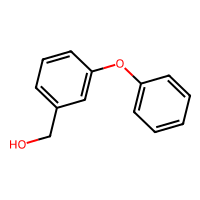

In [46]:
k = 2
k_hop_neighbors = nx.ego_graph(G, i, radius=k)
for j in k_hop_neighbors:
    print(G.nodes[j]['name'])
    print(G.nodes[j]['smiles'])
    display(SVG(draw_molecule(G.nodes[j]['smiles'])))